# Analysis of the current portfolio as of April 14, 2026

In [ ]:
# Import all the required libraries
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages


In [51]:
end_date = pd.Timestamp.today().normalize()
start_date = end_date - pd.DateOffset(years=40)

# Use S&P 500 index and MSCI World ETF proxy
symbols = {
    'S&P 500': '^GSPC',
    'MSCI World (URTH)': 'URTH'
}


In [52]:
# Download price data and compute the daily average of high and low
raw_prices = yf.download(list(symbols.values()), start=start_date, end=end_date, progress=False)

if isinstance(raw_prices.columns, pd.MultiIndex):
    level0 = raw_prices.columns.get_level_values(0)
    level1 = raw_prices.columns.get_level_values(1)
    if 'High' in level0 and 'Low' in level0:
        high = raw_prices.xs('High', axis=1, level=0)
        low = raw_prices.xs('Low', axis=1, level=0)
    elif 'High' in level1 and 'Low' in level1:
        high = raw_prices.xs('High', axis=1, level=1)
        low = raw_prices.xs('Low', axis=1, level=1)
    else:
        raise KeyError('Could not find High/Low fields in raw_prices columns.')
else:
    high = raw_prices['High']
    low = raw_prices['Low']

avg_prices = (high + low) / 2
if isinstance(avg_prices, pd.Series):
    avg_prices = avg_prices.to_frame(name=list(symbols.keys())[0])
else:
    avg_prices.columns = list(symbols.keys())

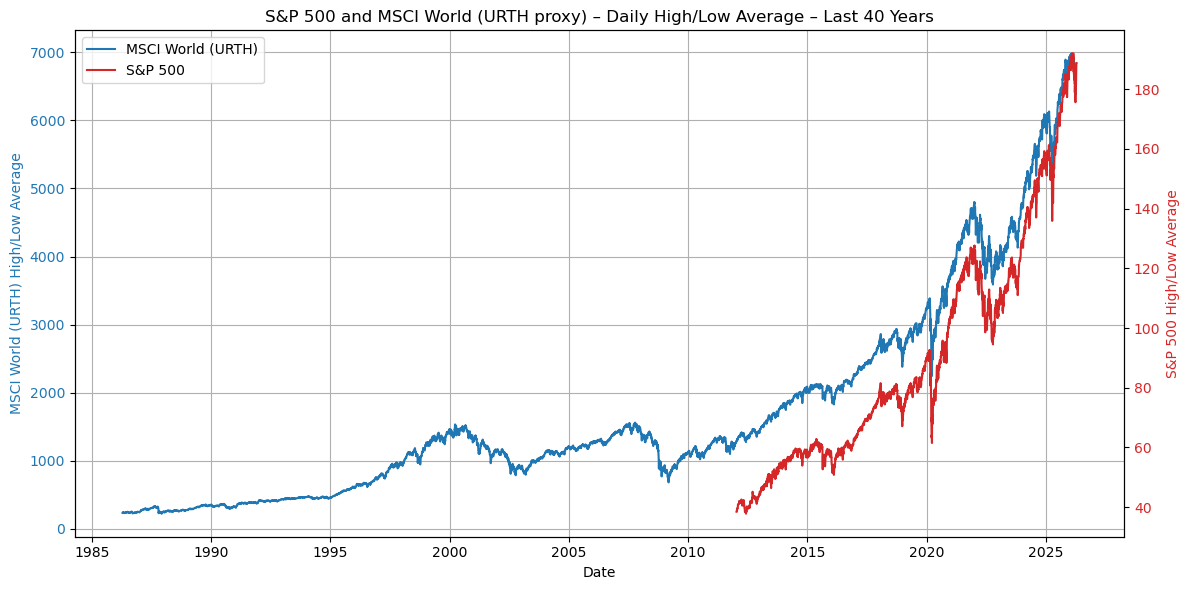

In [53]:
# Plot the average of daily high and low prices with separate y-axis scaling
fig, ax_left = plt.subplots(figsize=(12, 6))
ax_right = ax_left.twinx()

# Plot MSCI World on the left axis
ax_left.plot(avg_prices.index, avg_prices['MSCI World (URTH)'], label='MSCI World (URTH)', color='tab:blue')
ax_left.set_ylabel('MSCI World (URTH) High/Low Average', color='tab:blue')
ax_left.tick_params(axis='y', labelcolor='tab:blue')

# Plot S&P 500 on the right axis
ax_right.plot(avg_prices.index, avg_prices['S&P 500'], label='S&P 500', color='tab:red')
ax_right.set_ylabel('S&P 500 High/Low Average', color='tab:red')
ax_right.tick_params(axis='y', labelcolor='tab:red')

ax_left.set_title('S&P 500 and MSCI World (URTH proxy) – Daily High/Low Average – Last 40 Years')
ax_left.set_xlabel('Date')
ax_left.grid(True)

# Combine legends
lines_left, labels_left = ax_left.get_legend_handles_labels()
lines_right, labels_right = ax_right.get_legend_handles_labels()
ax_left.legend(lines_left + lines_right, labels_left + labels_right, loc='upper left')

fig.tight_layout()
plt.show()


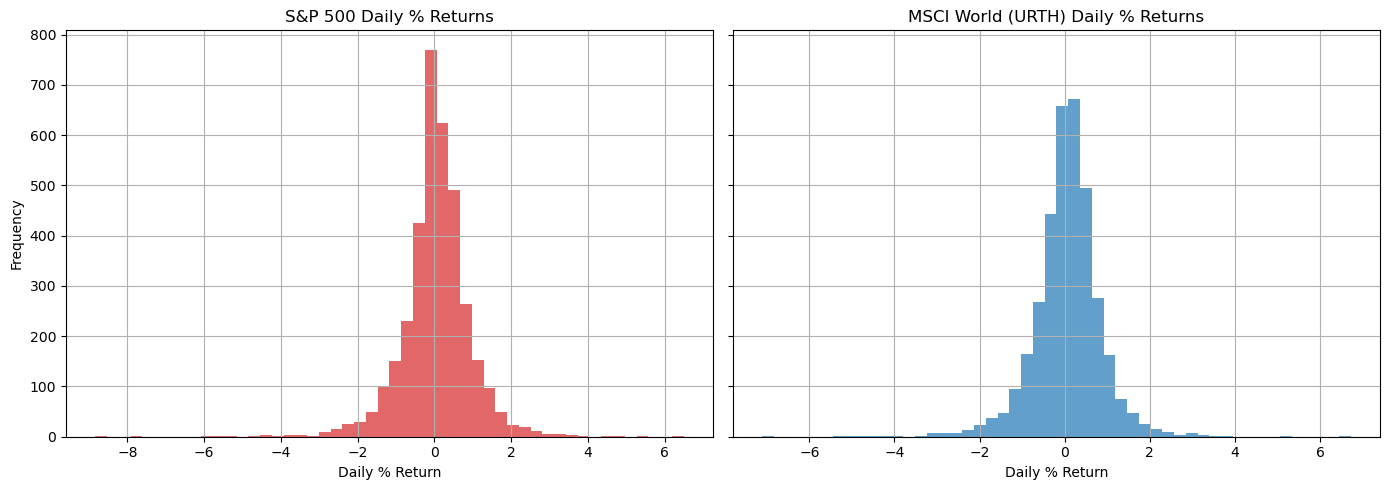

Mean daily % return:
S&P 500              0.048608
MSCI World (URTH)    0.049932
dtype: float64

Standard deviation of daily % returns:
S&P 500              0.913927
MSCI World (URTH)    0.820089
dtype: float64


In [54]:
# Compute daily percentage change for each ticker and plot histograms
returns = avg_prices.pct_change().dropna() * 100

mean_returns = returns.mean()
std_returns = returns.std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

returns['S&P 500'].hist(bins=50, ax=axes[0], color='tab:red', alpha=0.7)
axes[0].set_title('S&P 500 Daily % Returns')
axes[0].set_xlabel('Daily % Return')
axes[0].set_ylabel('Frequency')

returns['MSCI World (URTH)'].hist(bins=50, ax=axes[1], color='tab:blue', alpha=0.7)
axes[1].set_title('MSCI World (URTH) Daily % Returns')
axes[1].set_xlabel('Daily % Return')

fig.tight_layout()
plt.show()

print('Mean daily % return:')
print(mean_returns)
print('\nStandard deviation of daily % returns:')
print(std_returns)


In [55]:
# Compute monthly statistics for daily % returns
monthly_mean = returns.resample('YE').mean()
monthly_std = returns.resample('YE').std()

print('Monthly mean of daily % returns:')
print(monthly_mean)
print('\nMonthly standard deviation of daily % returns:')
print(monthly_std)

# Compute correlation between the two tickers
correlation = returns.corr()
print('\nCorrelation matrix of daily % returns:')
print(correlation)

Monthly mean of daily % returns:
             S&P 500  MSCI World (URTH)
Date                                   
2012-12-31  0.060640           0.039074
2013-12-31  0.100084           0.107699
2014-12-31  0.019914           0.047342
2015-12-31  0.003415          -0.000706
2016-12-31  0.032195           0.037393
2017-12-31  0.082716           0.071896
2018-12-31 -0.033685          -0.024759
2019-12-31  0.100082           0.103584
2020-12-31  0.070991           0.071502
2021-12-31  0.083273           0.098936
2022-12-31 -0.073537          -0.081640
2023-12-31  0.089917           0.091233
2024-12-31  0.071047           0.086525
2025-12-31  0.080935           0.064905
2026-12-31  0.022391          -0.003896

Monthly standard deviation of daily % returns:
             S&P 500  MSCI World (URTH)
Date                                   
2012-12-31  0.908710           0.636623
2013-12-31  1.153938           0.534647
2014-12-31  0.656089           0.554362
2015-12-31  1.070261           0.760210

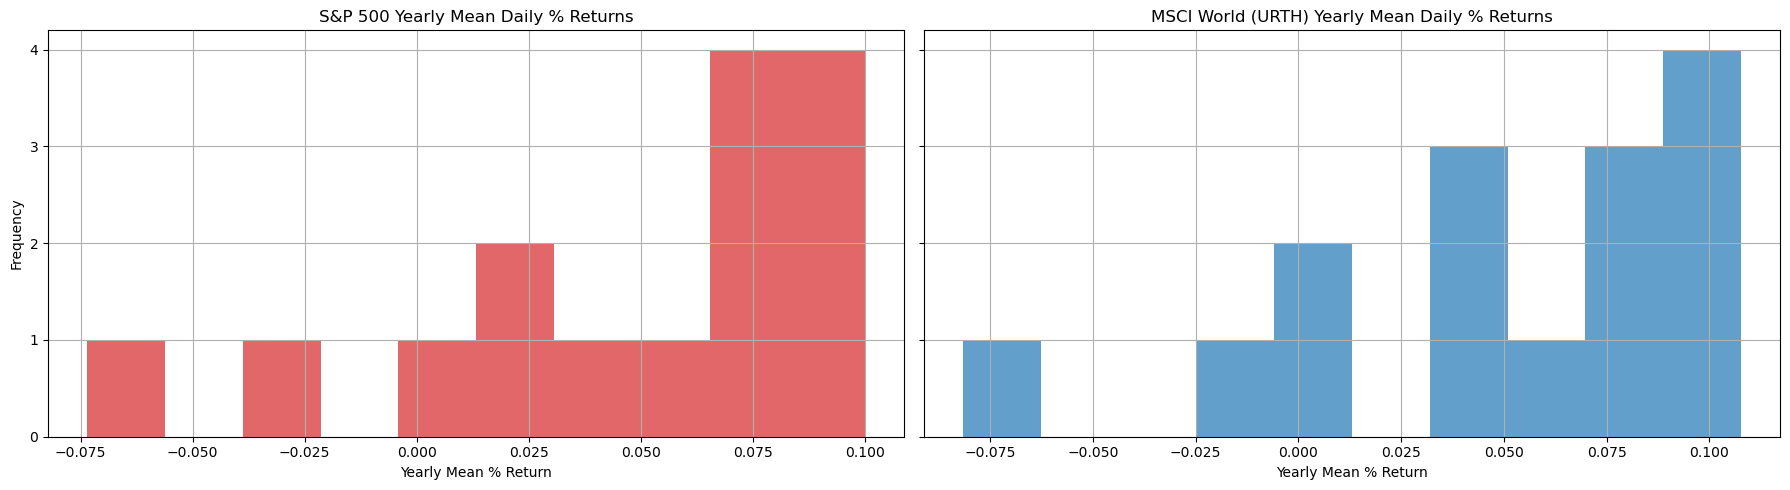

In [56]:
# Compute yearly statistics for daily % returns
yearly_mean = returns.resample('YE').mean()
yearly_std = returns.resample('YE').std()
'''
print('Yearly mean of daily % returns:')
print(yearly_mean)
print('\nYearly standard deviation of daily % returns:')
print(yearly_std)
'''
# Plot histograms for yearly measurements
fig, axes = plt.subplots(1, 2, figsize=(18, 5), sharey=True)

yearly_mean['S&P 500'].hist(bins=10, ax=axes[0], color='tab:red', alpha=0.7)
axes[0].set_title('S&P 500 Yearly Mean Daily % Returns')
axes[0].set_xlabel('Yearly Mean % Return')
axes[0].set_ylabel('Frequency')
axes[0].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

yearly_mean['MSCI World (URTH)'].hist(bins=10, ax=axes[1], color='tab:blue', alpha=0.7)
axes[1].set_title('MSCI World (URTH) Yearly Mean Daily % Returns')
axes[1].set_xlabel('Yearly Mean % Return')
axes[1].yaxis.set_major_locator(plt.MaxNLocator(integer=True))

fig.tight_layout()
plt.show()

In [67]:
from matplotlib.backends.backend_pdf import PdfPages
import seaborn as sns

def create_pdf_report(ticker_list, start_date, end_date, filename='portfolio_report.pdf'):
    """
    Create a PDF report for a list of tickers (used as ISIN proxies).
    Includes histograms of monthly and yearly % returns, table of yearly stats, and covariance matrix plot.
    """
    # Download data
    raw_prices = yf.download(ticker_list, start=start_date, end=end_date, progress=False)

    if isinstance(raw_prices.columns, pd.MultiIndex):
        level0 = raw_prices.columns.get_level_values(0)
        level1 = raw_prices.columns.get_level_values(1)
        if 'High' in level0 and 'Low' in level0:
            high = raw_prices.xs('High', axis=1, level=0)
            low = raw_prices.xs('Low', axis=1, level=0)
        elif 'High' in level1 and 'Low' in level1:
            high = raw_prices.xs('High', axis=1, level=1)
            low = raw_prices.xs('Low', axis=1, level=1)
        else:
            raise KeyError('Could not find High/Low fields in raw_prices columns.')
    else:
        high = raw_prices['High']
        low = raw_prices['Low']

    prices = (high + low) / 2
    prices.columns = ticker_list

    # Compute returns
    returns = prices.pct_change().dropna() * 100

    # Yearly returns (annual percentage return per year)
    yearly_returns = (prices.resample('YE').last() / prices.resample('YE').first() - 1) * 100
    yearly_mean = yearly_returns.mean()
    yearly_std = yearly_returns.std()

    # Correlation matrix
    corr_matrix = returns.corr()

    # Create PDF
    with PdfPages(filename) as pdf:
        # Histograms for daily returns
        for ticker in ticker_list:
            fig, ax = plt.subplots(figsize=(8, 6))
            returns[ticker].hist(bins=50, ax=ax, color='lightblue', alpha=0.7)
            ax.set_title(f'Daily % Returns for {ticker}')
            ax.set_xlabel('Daily % Return')
            ax.set_ylabel('Frequency')
            pdf.savefig(fig)
            plt.close(fig)

        # Table of yearly stats
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.axis('tight')
        ax.axis('off')
        table_data = [['Asset', 'Expected Yearly Return (%)', 'Std Dev (%)']]
        for ticker in ticker_list:
            table_data.append([ticker, f"{yearly_mean[ticker]:.2f}", f"{yearly_std[ticker]:.2f}"])
        table = ax.table(cellText=table_data, colLabels=None, cellLoc='center', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1.2, 1.2)
        ax.set_title('Yearly Statistics')
        pdf.savefig(fig)
        plt.close(fig)

        # Portfolio expected return (30% asset1, 70% asset2)
        if len(ticker_list) >= 2:
            w1, w2 = 0.3, 0.7
            asset1, asset2 = ticker_list[0], ticker_list[1]
            portfolio_return = w1 * yearly_mean[asset1] + w2 * yearly_mean[asset2]
            # Portfolio std dev
            var1 = yearly_std[asset1]**2
            var2 = yearly_std[asset2]**2
            cov12 = corr_matrix.loc[asset1, asset2] * yearly_std[asset1] * yearly_std[asset2]
            portfolio_var = w1**2 * var1 + w2**2 * var2 + 2 * w1 * w2 * cov12
            portfolio_std = portfolio_var**0.5
            # Portfolio beta (assuming asset1 is market)
            market = asset1
            cov_port_market = w1 * (corr_matrix.loc[asset1, market] * yearly_std[asset1] * yearly_std[market]) + \
                              w2 * (corr_matrix.loc[asset2, market] * yearly_std[asset2] * yearly_std[market])
            var_market = yearly_std[market]**2
            portfolio_beta = cov_port_market / var_market if var_market != 0 else 0
            fig, ax = plt.subplots(figsize=(8, 4))
            ax.axis('tight')
            ax.axis('off')
            table_data = [['Portfolio Allocation', 'Expected Yearly Return (%)', 'Std Dev (%)', 'Beta']]
            table_data.append([f'{int(w1*100)}% {asset1}, {int(w2*100)}% {asset2}', f"{portfolio_return:.2f}", f"{portfolio_std:.2f}", f"{portfolio_beta:.2f}"])
            table = ax.table(cellText=table_data, colLabels=None, cellLoc='center', loc='center')
            table.auto_set_font_size(False)
            table.set_fontsize(10)
            table.scale(1.2, 1.2)
            ax.set_title('Portfolio Expected Return, Volatility, and Beta')
            pdf.savefig(fig)
            plt.close(fig)

        # Correlation matrix heatmap
        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', ax=ax)
        ax.set_title('Correlation Matrix of Daily Returns')
        pdf.savefig(fig)
        plt.close(fig)

    print(f"PDF report saved as {filename}")

# Example usage (assuming ticker_list is the list of ISINs/tickers)
ticker_list = list(symbols.values())  # ['^GSPC', 'URTH']
create_pdf_report(ticker_list, start_date, end_date)

PDF report saved as portfolio_report.pdf
